# Entrenamiento de modelo de predicción de puntuación


## Importación de librerias necesarias


In [ ]:
%load_ext IPython.extensions.autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import sys

def find_src_folder(current_path: Path, folder_name: str = 'src') -> Path:
    search_directories = [current_path] + list(current_path.parents)
    for parent in search_directories:
        if parent.name == folder_name:
            return parent.parent
    return current_path

src_path = find_src_folder(Path.cwd(), 'src')
sys.path.append(str(src_path))

print(f"JAVA_HOME: {os.environ.get('JAVA_HOME')}")
print(f"TFHUB_CACHE_DIR: {os.environ.get('TFHUB_CACHE_DIR')}")


JAVA_HOME: /usr/lib/jvm/java-11-openjdk-amd64
TFHUB_CACHE_DIR: /mnt/d/Maestría/Amazon Reviews Code/tf_cache


In [3]:
import numpy as np
import pandas as pd
import sys
import os
import shutil
import tensorflow as tf
import tensorflow_io as tfio
from pyspark.sql import functions as F, types as T, DataFrame
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from pyspark.ml.functions import array_to_vector, vector_to_array
from pyspark.ml.feature import VectorAssembler


2025-10-19 13:23:44.876188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-19 13:23:45.033892: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-19 13:23:45.072354: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-19 13:23:45.337888: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-19 13:23:48.283226: W tensorflow/compiler/tf2

In [4]:
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print(f"TensorFlow version: {tf.__version__}")
print(f"CUDA built: {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpus}")

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(f"GPU memory growth error: {e}")

if gpus:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
        b = tf.constant([[2.0, 0.0], [0.0, 2.0]])
        c = tf.matmul(a, b)
        print(f"GPU test result: {c.numpy()}")
        print("✓ GPU is working!")
else:
    print("❌ No GPU detected")


Python executable: /mnt/d/Maestría/Amazon Reviews Code/.venv-linux/bin/python
Python version: 3.11.13 (main, Jun  4 2025, 08:57:30) [GCC 13.3.0]
TensorFlow version: 2.17.1
CUDA built: True
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled
GPU test result: [[2. 4.]
 [6. 8.]]
✓ GPU is working!


I0000 00:00:1760898236.252588   12937 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760898236.558122   12937 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760898236.558332   12937 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1760898236.560247   12937 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [5]:
from src.utils.spark import SparkUtils, METASTORE_PATH
spark_utils = SparkUtils('predict_category_model')
spark = spark_utils.spark


:: loading settings :: url = jar:file:/mnt/d/Maestr%c3%ada/Amazon%20Reviews%20Code/.venv-linux/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/edgar/.ivy2/cache
The jars for the packages stored in: /home/edgar/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-f62f53a1-63d1-4ea7-9ae3-22edbd01a1e9;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 149ms :: artifacts dl 6ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.0.0 from central in [default]
	io.delta#delta-storage;3.0.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   

## Cargar datos fuente de entrenamiento


In [6]:
GOLD_ENCODING = 'gold.encoding'
GOLD_PREMODELING = 'gold.premodeling'
GOLD_SCHEMA_CLUSTER = 'gold.cluster'
SCHEMA = 'silver.preprocess'


In [7]:
REGENERATE_MODEL = False


In [8]:
src_dir_boolean = f"{METASTORE_PATH}/warehouse/gold.premodeling/final_training_data_rating_array_boolean"
dst_dir_boolean = f"{METASTORE_PATH}/warehouse/gold.premodeling/dataset_score_model_boolean"
dst_path_boolean = os.path.join(dst_dir_boolean, "dataset_training.parquet")


In [9]:
from src.utils.models import BinaryModel


In [10]:
binary_model = BinaryModel('binary_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")


In [11]:
binary_model.prepare_data(
    spark, src_dir_boolean, dst_dir_boolean, dst_path_boolean, target_column=b"rating_boolean", shuffle_buffer_size = -1,
    train_ratio=0.8, val_ratio=0.1
)


2025-10-19 13:24:11.925183: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


## Crear modelo de predicción


In [12]:
binary_model.create_model()


<Sequential name=sequential, built=True>

In [13]:
if True:
    history_model_binary = binary_model.train(epochs=20)


Epoch 1/20


I0000 00:00:1760898284.506394   13216 service.cc:146] XLA service 0x78d244018470 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760898284.506417   13216 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050, Compute Capability 8.6
2025-10-19 13:24:44.551114: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-19 13:24:44.760361: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


      4/Unknown 9s 49ms/step - accuracy: 0.6126 - loss: 0.6906

I0000 00:00:1760898286.300857   13216 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


      7/Unknown 10s 309ms/step - accuracy: 0.6148 - loss: 0.6981

...

2025-10-19 13:27:44.307471: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13629877333028774419
2025-10-19 13:27:44.307509: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12688707406918329873


6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9863 - loss: 0.0602

2025-10-19 13:27:48.795061: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13629877333028774419
2025-10-19 13:27:48.795095: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12688707406918329873



Epoch 20: val_loss did not improve from 0.01256
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 781ms/step - accuracy: 0.9912 - loss: 0.0442 - val_accuracy: 1.0000 - val_loss: 0.0161 - learning_rate: 2.5000e-04
Epoch 20: early stopping
Restoring model weights from the end of the best epoch: 17.


2025-10-19 13:27:53.042123: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 13629877333028774419
2025-10-19 13:27:53.042159: I tensorflow/core/framework/local_rendezvous.cc:423] Local rendezvous recv item cancelled. Key hash: 12688707406918329873


2025/10/19 13:27:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/19 13:27:55 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/10/19 13:28:08 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


da3b31aaa4664d86a48d473d0d937d68
Plot saved to /mnt/d/Maestría/Amazon Reviews Code/data/warehouse/gold.premodeling/training_history_binary_model.png


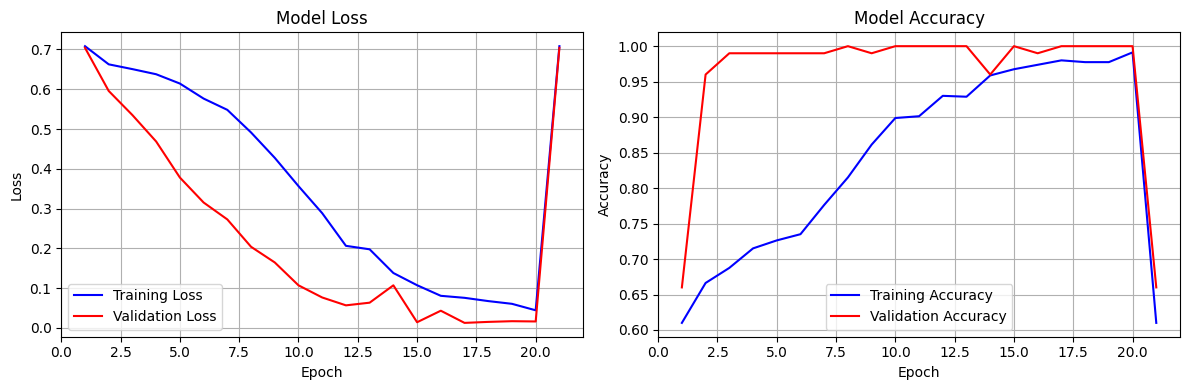

In [14]:
if True:
    for name, model in [
        ("binary_model", binary_model)
    ]:

        tags = {
            "model_type": "neural_network",
            "task": "rating_prediction",
            "dataset": "amazon_reviews",
            "variant": name
        }
 
        exp = model.log_training_history(
            run_name=f"{name}_{model.input_shape}features",
            tags=tags
        )

        print(exp)

        _ = model.plot_training_history(
            save_path=f"{METASTORE_PATH}/warehouse/gold.premodeling/training_history_{name}.png"
        )


## Cargar modelo


In [15]:
from src.utils.models import BinaryModel
binary_model = BinaryModel('binary_model', METASTORE_PATH, tracking_uri="file:///mnt/d/Maestría/Amazon Reviews Code/.mlflow")
binary_model.load_latest_model()


/mnt/d/Maestría/Amazon Reviews Code/.venv-linux/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [16]:
binary_model.list_available_models()



Available Model Versions (filtered by: binary_model)

1. Run ID: da3b31aaa4664d86a48d473d0d937d68
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 18:27:54.745000+00:00
   End Time: 2025-10-19 18:28:08.397000+00:00
   Metrics: Loss: 0.0442, Val Loss: 0.0161, Accuracy: 0.9912, Val Accuracy: 1.0000

2. Run ID: a37b31c6482c44ce9b6feece646ba2cf
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 14:45:07.116000+00:00
   End Time: 2025-10-19 14:45:17.536000+00:00
   Metrics: Loss: 0.3411, Val Loss: 0.5678, Accuracy: 0.8900, Val Accuracy: 0.6733

3. Run ID: 74fc9bd2c7a2466b840dc65d0a564833
   Run Name: binary_model_1025features
   Model Name: 
   Status: FINISHED
   Start Time: 2025-10-19 14:33:39.761000+00:00
   End Time: 2025-10-19 14:33:53.174000+00:00
   Metrics: Loss: 0.6873, Val Loss: 0.7262, Accuracy: 0.6200, Val Accuracy: 0.5600



In [17]:
X_test, y_test = next(iter(binary_model.val_dataset.take(1)))


AttributeError: 'NoneType' object has no attribute 'take'

In [ ]:
X_test.shape


In [ ]:
y_pred = binary_model.predict(X_test.numpy())


In [ ]:
def predict_rating(model, features):
    if len(features.shape) == 1:
        features = features.reshape(1, -1)
    probabilities = model.predict(features, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    return predictions, probabilities

test_batch = next(iter(binary_model.val_dataset.take(1)))
X_test, y_test = test_batch
predictions, probabilities = predict_rating(binary_model.model, X_test.numpy())


In [ ]:
binary_model.get_model_versions()
